Test

In [4]:
import numpy as np
import scipy.stats as scp
import numpy.random as rnd
import matplotlib.pyplot as plt
import librosa as lb

# 1

## a

In [5]:
%matplotlib inline

In [6]:
states = np.arange(0,11,1)

In [7]:
statetransitions = np.zeros((len(states),len(states)))
statetransitions[0][0] = 0.9
statetransitions[0][1] = 0.1
statetransitions[10][-1] = 0.9
statetransitions[10][-2] = 0.1

for i in range(len(states)-2):
        
    statetransitions[i+1][0] = 0.1
    statetransitions[i+1][1] = 0.8
    statetransitions[i+1][2] = 0.1
    statetransitions[i+1] = np.roll(statetransitions[i+1],i)
    

In [8]:
statetransitions

array([[0.9, 0.1, 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ],
       [0.1, 0.8, 0.1, 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ],
       [0. , 0.1, 0.8, 0.1, 0. , 0. , 0. , 0. , 0. , 0. , 0. ],
       [0. , 0. , 0.1, 0.8, 0.1, 0. , 0. , 0. , 0. , 0. , 0. ],
       [0. , 0. , 0. , 0.1, 0.8, 0.1, 0. , 0. , 0. , 0. , 0. ],
       [0. , 0. , 0. , 0. , 0.1, 0.8, 0.1, 0. , 0. , 0. , 0. ],
       [0. , 0. , 0. , 0. , 0. , 0.1, 0.8, 0.1, 0. , 0. , 0. ],
       [0. , 0. , 0. , 0. , 0. , 0. , 0.1, 0.8, 0.1, 0. , 0. ],
       [0. , 0. , 0. , 0. , 0. , 0. , 0. , 0.1, 0.8, 0.1, 0. ],
       [0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0.1, 0.8, 0.1],
       [0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0.1, 0.9]])

## B

In [9]:
cumstatetransitions = np.cumsum(statetransitions,axis=1)

In [10]:
cumstatetransitions

array([[0.9, 1. , 1. , 1. , 1. , 1. , 1. , 1. , 1. , 1. , 1. ],
       [0.1, 0.9, 1. , 1. , 1. , 1. , 1. , 1. , 1. , 1. , 1. ],
       [0. , 0.1, 0.9, 1. , 1. , 1. , 1. , 1. , 1. , 1. , 1. ],
       [0. , 0. , 0.1, 0.9, 1. , 1. , 1. , 1. , 1. , 1. , 1. ],
       [0. , 0. , 0. , 0.1, 0.9, 1. , 1. , 1. , 1. , 1. , 1. ],
       [0. , 0. , 0. , 0. , 0.1, 0.9, 1. , 1. , 1. , 1. , 1. ],
       [0. , 0. , 0. , 0. , 0. , 0.1, 0.9, 1. , 1. , 1. , 1. ],
       [0. , 0. , 0. , 0. , 0. , 0. , 0.1, 0.9, 1. , 1. , 1. ],
       [0. , 0. , 0. , 0. , 0. , 0. , 0. , 0.1, 0.9, 1. , 1. ],
       [0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0.1, 0.9, 1. ],
       [0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0.1, 1. ]])

In [11]:
numexperiments = 10
numtimesteps = 50
posarr = np.zeros([numexperiments,numtimesteps])
posarr[:,0] = 5

for experiment in range(numexperiments):
    rand = rnd.uniform(low=0,high=1,size=numtimesteps)
    for currenttime in range(1,numtimesteps):
        for state in range(len(statetransitions)):
            lastposition = int(posarr[experiment,currenttime-1])
            if rand[currenttime] < cumstatetransitions[lastposition][state]:
                posarr[experiment,currenttime] = state
                break
posarr = np.transpose(posarr)


Text(0.5, 0.98, '10 Random walks')

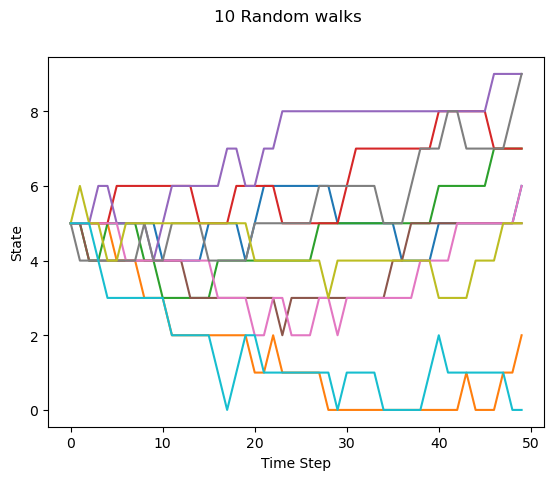

In [12]:
fig, ax = plt.subplots()
ax.plot(posarr)
ax.set_xlabel("Time Step")
ax.set_ylabel("State")
# ax.set_xlim(0,3)
fig.suptitle("10 Random walks")

## C

We can find the PMF empirecally or with a heck ton of simulations (monte carlo? Is that what this is? I've done it in phys64 and this feels similar, trying to guess a thing and approach it?)

## Math PMF

In [13]:
def matrixpower(mat,pow):
    if(pow == 0):
        return mat
    else:
        return mat@matrixpower(mat,pow-1)

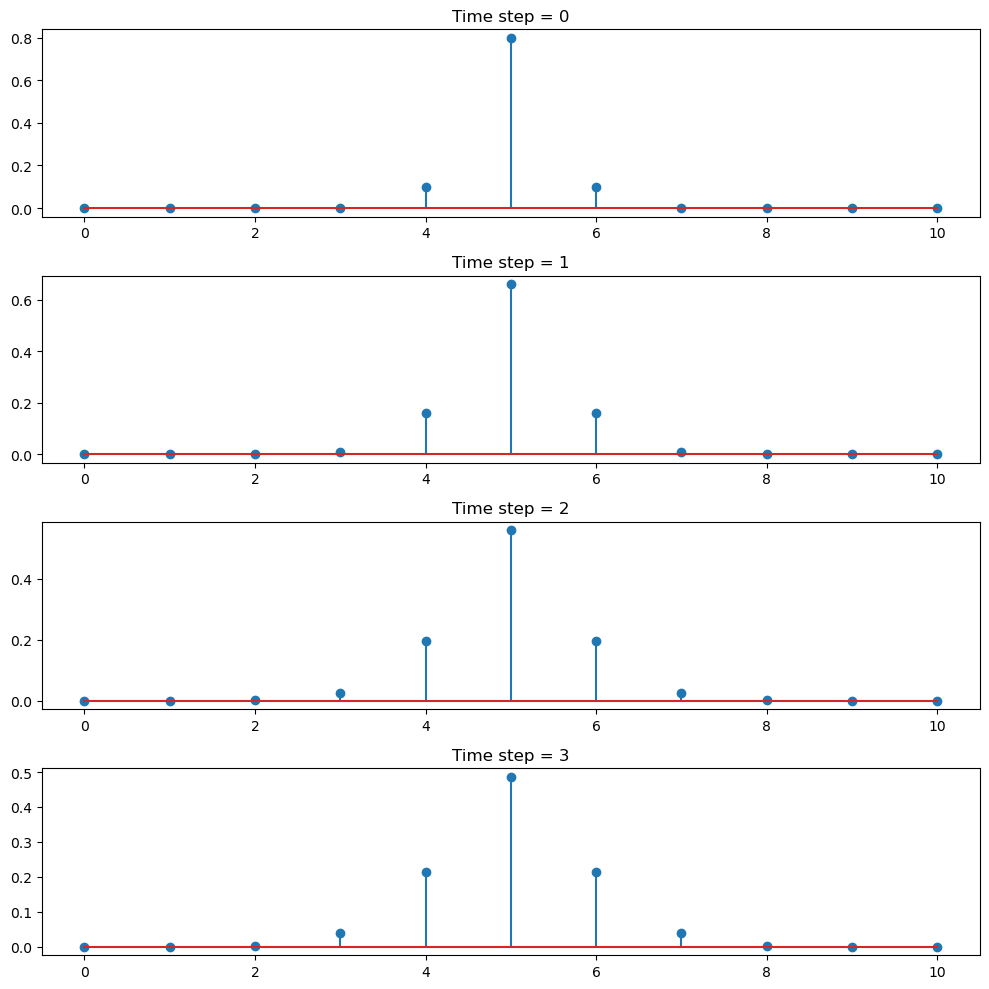

In [14]:
numsteps = 4
fig, ax = plt.subplots(numsteps,figsize=(10,10))
for i in range(numsteps):
    # pow = np.power(statetransitions,i)
    pow = matrixpower(statetransitions,i)
    currentpositionpmf = pow[5,:]
    # print(f"SUM: {np.sum(currentpositionpmf)}")
    # print(i)
    ax[i].stem(currentpositionpmf)
    ax[i].set_title("Time step = " + str(i))
    # ax[i].set_ylim(0,1)

    fig.tight_layout()


out of curiosity, I compare this with the simulated PMF but gave up because density doesn't work with weird binsizes?

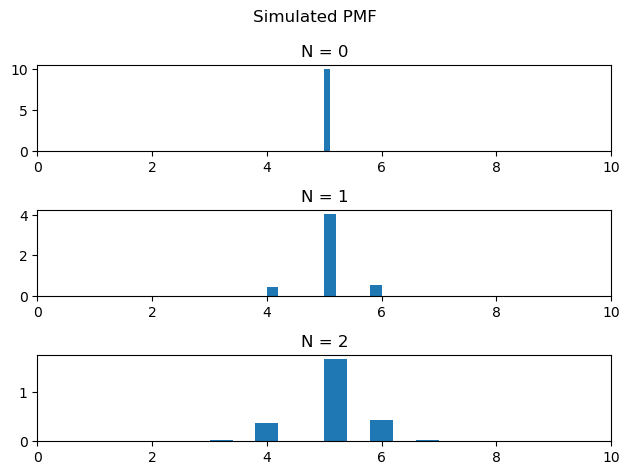

In [15]:
numexperiments = 1000
numtimesteps = 50
posarr = np.zeros([numexperiments,numtimesteps])
posarr[:,0] = 5

for experiment in range(numexperiments):
    rand = rnd.uniform(low=0,high=1,size=numtimesteps)
    for currenttime in range(1,numtimesteps):
        for state in range(len(statetransitions)):
            lastposition = int(posarr[experiment,currenttime-1])
            if rand[currenttime] < cumstatetransitions[lastposition][state]:
                posarr[experiment,currenttime] = state
                break
posarr = np.transpose(posarr)

numplottimesteps = 3
fig, ax = plt.subplots(numplottimesteps,1)
for i in range(numplottimesteps):
    # print(f"Data = {posarr[i,:]}")
    counts,bins = np.histogram(posarr[i,:])
    ax[i].hist(posarr[i,:],density=True)#,density=True,align="mid")
    ax[i].set_xlim(0,10)
    ax[i].set_title("N = " + str(i))
fig.suptitle("Simulated PMF")
fig.tight_layout()
# ax.plot(posarr)
# ax.set_xlabel("Time Step")
# ax.set_ylabel("State")
# fig.suptitle("10 Random walks")



## d

To find where the PMF was constant, we define a threshold 0.001 where the every value of the pmf for that number of steps and that number of steps + a huge number are within that threshold of each other. This means that the are in steady state - the pmf doesn't change even over massive timespans.

161


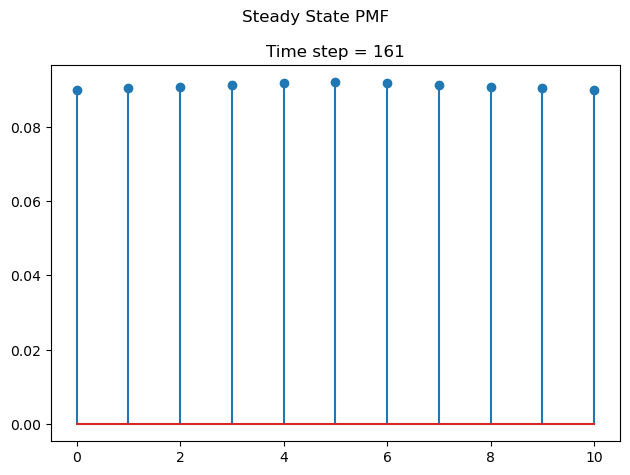

In [16]:
gooddiff = False

stepsaway = 1000
threshold = 0.001
minval = 1
while(not gooddiff):
    
    pow1 = matrixpower(statetransitions,minval)
    pow2 = matrixpower(statetransitions,minval+stepsaway)
    diff = np.abs(pow1[5,:]-pow2[5,:])
    # print(diff)
    if(np.all(diff<= threshold)):
        gooddiff = True
        print(minval)
    else:
        minval = minval + 1

fig, ax = plt.subplots()

ax.stem(pow1[5,:])

ax.set_title("Time step = " + str(minval))
fig.suptitle("Steady State PMF")

# ax.set_ylim(0,1)

fig.tight_layout()


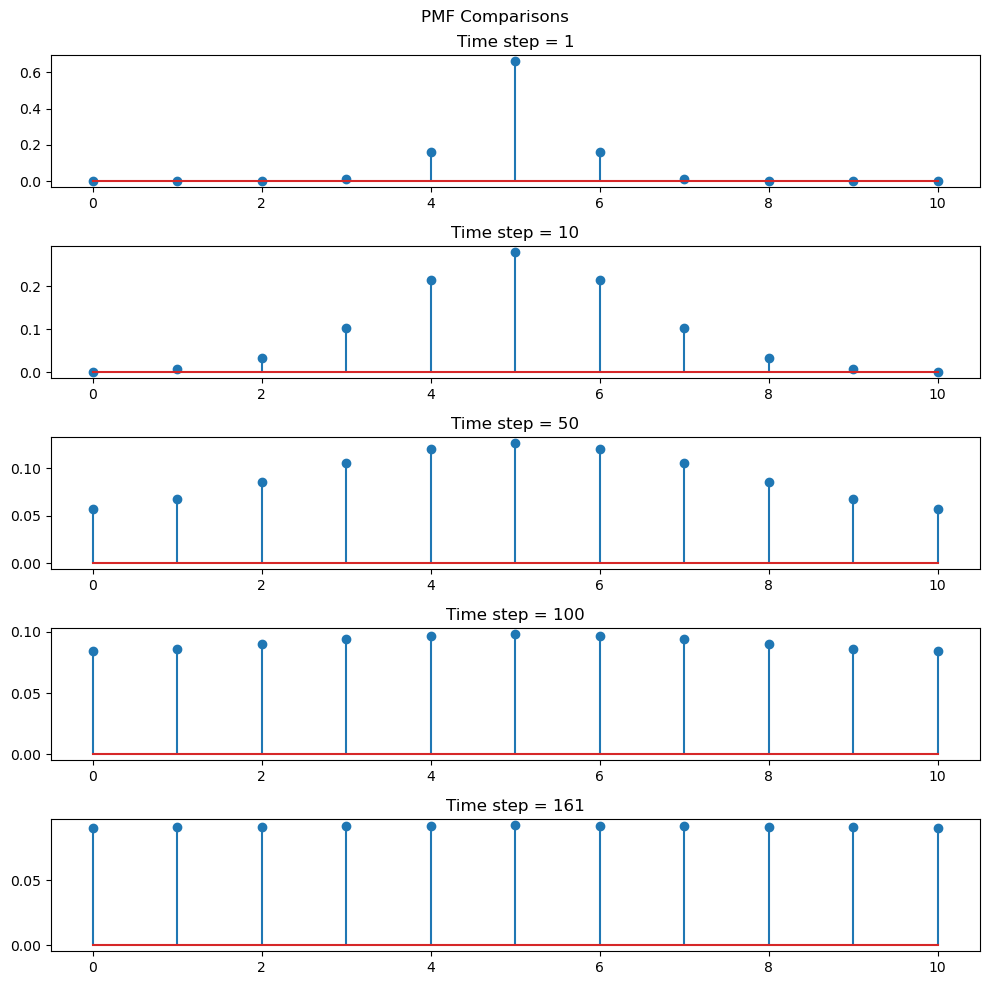

In [17]:
gooddiff = False

stepsaway = 1000
threshold = 0.001
minval = 1

timestepsarr = [1,10,50,100,161]

fig, ax = plt.subplots(len(timestepsarr),figsize=(10,10))
for i in range(len(timestepsarr)):

    pow = matrixpower(statetransitions,timestepsarr[i])
    ax[i].stem(pow[5,:])

    ax[i].set_title("Time step = " + str(timestepsarr[i]))
fig.suptitle("PMF Comparisons")

# ax.set_ylim(0,1)

fig.tight_layout()


## E

In [18]:
numexperiments = 10
numtimesteps = 50
posarr = np.zeros([numexperiments,numtimesteps])
posarr[:,0] = 5

for experiment in range(numexperiments):
    rand = rnd.uniform(low=0,high=1,size=numtimesteps)
    for currenttime in range(1,numtimesteps):
        for state in range(len(statetransitions)):
            lastposition = int(posarr[experiment,currenttime-1])
            if rand[currenttime] < cumstatetransitions[lastposition][state]:
                posarr[experiment,currenttime] = state
                break
posarr = np.transpose(posarr)


In [19]:

path = posarr[:,7]
# plt.plot(path)

In [20]:
variances = [0.1,0.5,1]
variancenames = ["low","med","high"]
noises = np.zeros((3,len(path)))
for i in range(len(variances)):
    noises[i,:] = rnd.normal(0,variances[i],len(path))

In [21]:
# np.shape(noises[1,:])

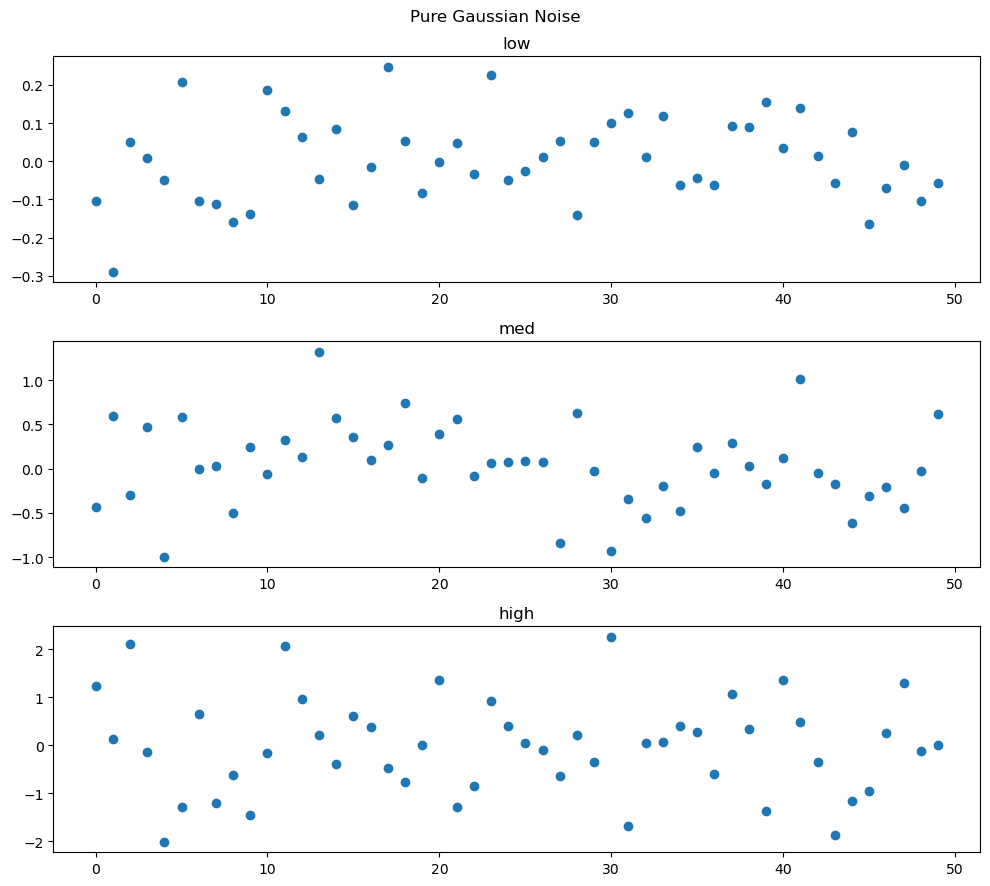

In [22]:
fig, ax = plt.subplots(numplottimesteps,1,figsize=(10,9))
for i in range(len(variances)):
    ax[i].scatter(np.arange(len(noises[i,:])),noises[i,:])
    ax[i].set_title(variancenames[i])
fig.suptitle("Pure Gaussian Noise")
fig.tight_layout()


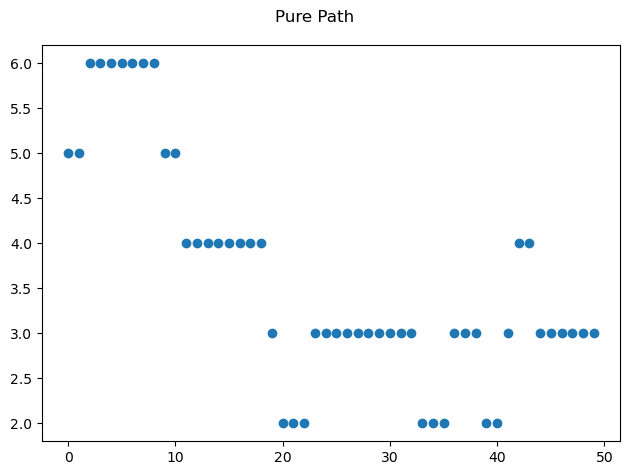

In [23]:
fig, ax = plt.subplots(1)
ax.scatter(np.arange(len(path)),path)    
fig.suptitle("Pure Path")
fig.tight_layout()

<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:4: SyntaxWarning: invalid escape sequence '\s'
C:\Users\Sorin\AppData\Local\Temp\ipykernel_45500\4239940391.py:4: SyntaxWarning: invalid escape sequence '\s'
  ax[i].set_title(variancenames[i] + " $\sigma^2=$" + str(variances[i]))


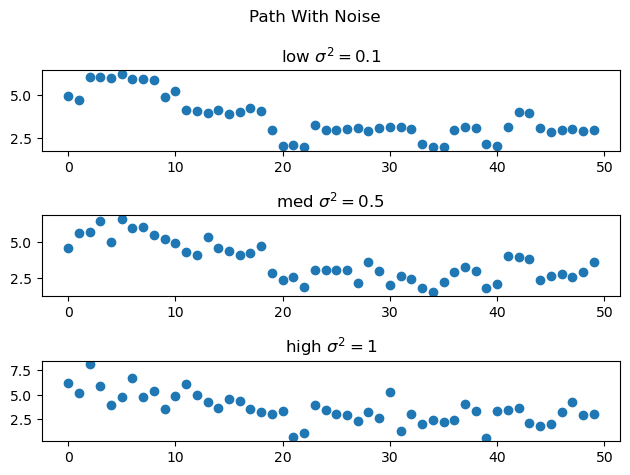

In [24]:
fig, ax = plt.subplots(numplottimesteps,1)#,figsize=(10,9))
for i in range(len(variances)):
    ax[i].scatter(np.arange(len(path)),path+noises[i,:])
    ax[i].set_title(variancenames[i] + " $\sigma^2=$" + str(variances[i]))
    # ax[i].set_ylim(0,12)
fig.suptitle("Path With Noise")
fig.tight_layout()

## F

We have two ways that we came up with to do this. One if we know the variance, and one if we don't know the variance. 

If we know the variance, we can model each with a continuous gaussian distribution. If we don't know the variance, than we can still make the PDF, and just find the closest value (or could make it more complicated by considering the two closest values and adding the PDFs for those, something along those lines).

First, lets do the poor method (not knowing the variance). This is just done for fun, but we found it interesting enough to keep in the assignment.

In [25]:
def constructSimilarityMatrix(pathObserved):
    numtimes = 50
    numstates = 11

    probabilityMatrix = np.zeros((numstates,numtimes))

    for i in range(numtimes):
        pow = matrixpower(statetransitions,i)
        observation = pathObserved[i]
        for j in range(numstates):
            pdf =  pow[j,:]

            lower = int(np.floor(observation))
            upper = int(np.ceil(observation))
            if(upper > numstates):
                upper = 9999
            if(lower > 10):
                lower = 0
            if(np.abs(observation-lower) < np.abs(upper-observation) or upper >= numstates-1):
                # print(f"lower: {lower}")
                probabilityMatrix[j,i] = probabilityMatrix[j,i] + pdf[lower]
            else:
                # print(f"upper: {upper}")
                probabilityMatrix[j,i] = probabilityMatrix[j,i] + pdf[upper]

    return probabilityMatrix

In [26]:
variances

[0.1, 0.5, 1]

In [27]:
pathset = np.array([path,path+noises[0,:],path+noises[1,:],path+noises[2,:]])
pathnames = ["pure", "low noise", "medium noise", "high noise"]

In [28]:
np.shape(pathset)

(4, 50)

In [29]:
similarities = []
for i in range(np.shape(pathset)[0]):
    similarities.append(constructSimilarityMatrix(pathset[i,:]))

In [30]:
np.shape(similarities[1][1,:])

(50,)

In [31]:
states = np.zeros((4,50))
for i in range(4):
    states[i,:] = lb.sequence.viterbi(prob=similarities[i],transition=statetransitions)
# statesnoisemed = lb.sequence.viterbi(prob=noisepathSimilarityMed,transition=statetransitions)
# statesnoiselarge = lb.sequence.viterbi(prob=noisepathSimilarityLarge,transition=statetransitions)

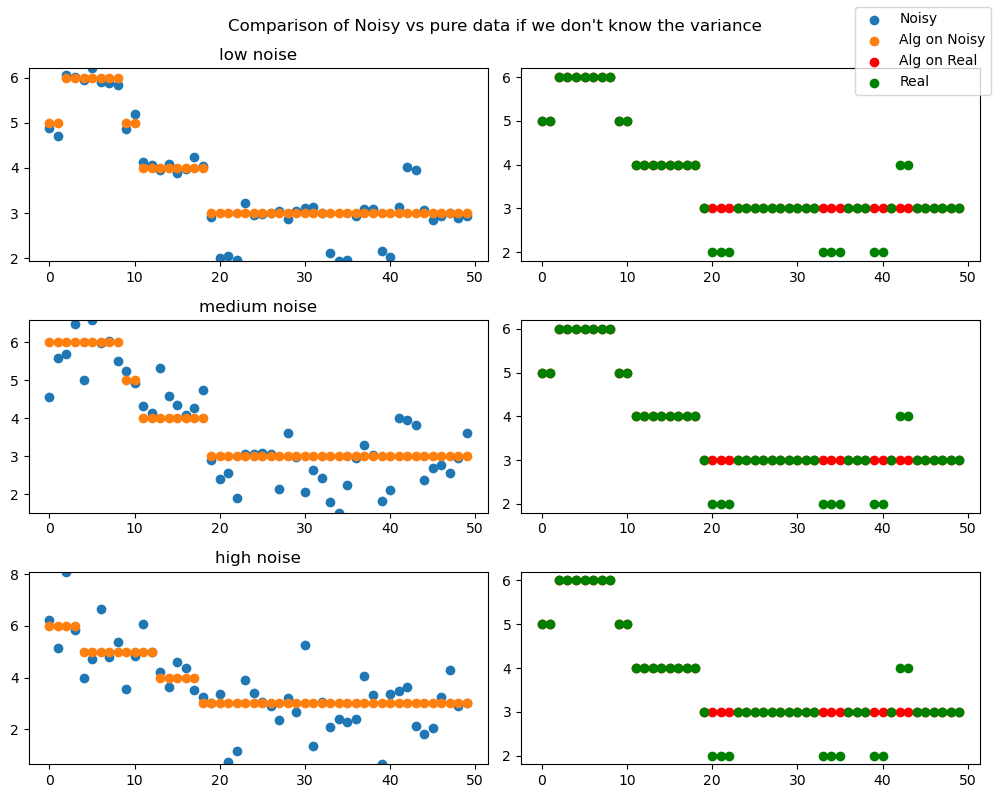

In [32]:
fig, ax = plt.subplots(3,2,figsize=(10,8))
for i in range(1,4):
    
    ax[i-1][0].scatter(np.arange(len(states[i,:])),pathset[i,:]) # noisy data
    ax[i-1][0].scatter(np.arange(len(states[i,:])),states[i,:]) # algorithm on noisy data
    ax[i-1][1].scatter(np.arange(len(states[0,:])),states[0,:],color="red") # algorithm on real data
    ax[i-1][1].scatter(np.arange(len(states[0,:])),path,color="green") # real data
    
    ax[i-1][0].set_title(pathnames[i])
    ax[i-1][0].set_ylim((min(min(path),min(pathset[i,:])),max(max(path),max(pathset[i,:]))))
fig.legend(["Noisy","Alg on Noisy","Alg on Real","Real"])
fig.suptitle("Comparison of Noisy vs pure data if we don't know the variance")
fig.tight_layout()

Now lets do the proper way, where we know the variance

<>:47: SyntaxWarning: invalid escape sequence '\s'
<>:47: SyntaxWarning: invalid escape sequence '\s'
C:\Users\Sorin\AppData\Local\Temp\ipykernel_45500\3082797552.py:47: SyntaxWarning: invalid escape sequence '\s'
  Axes[Index].set_title(f"Estimated vs. True Path With {Name} Noise ($\sigma^2=$ {Value})")


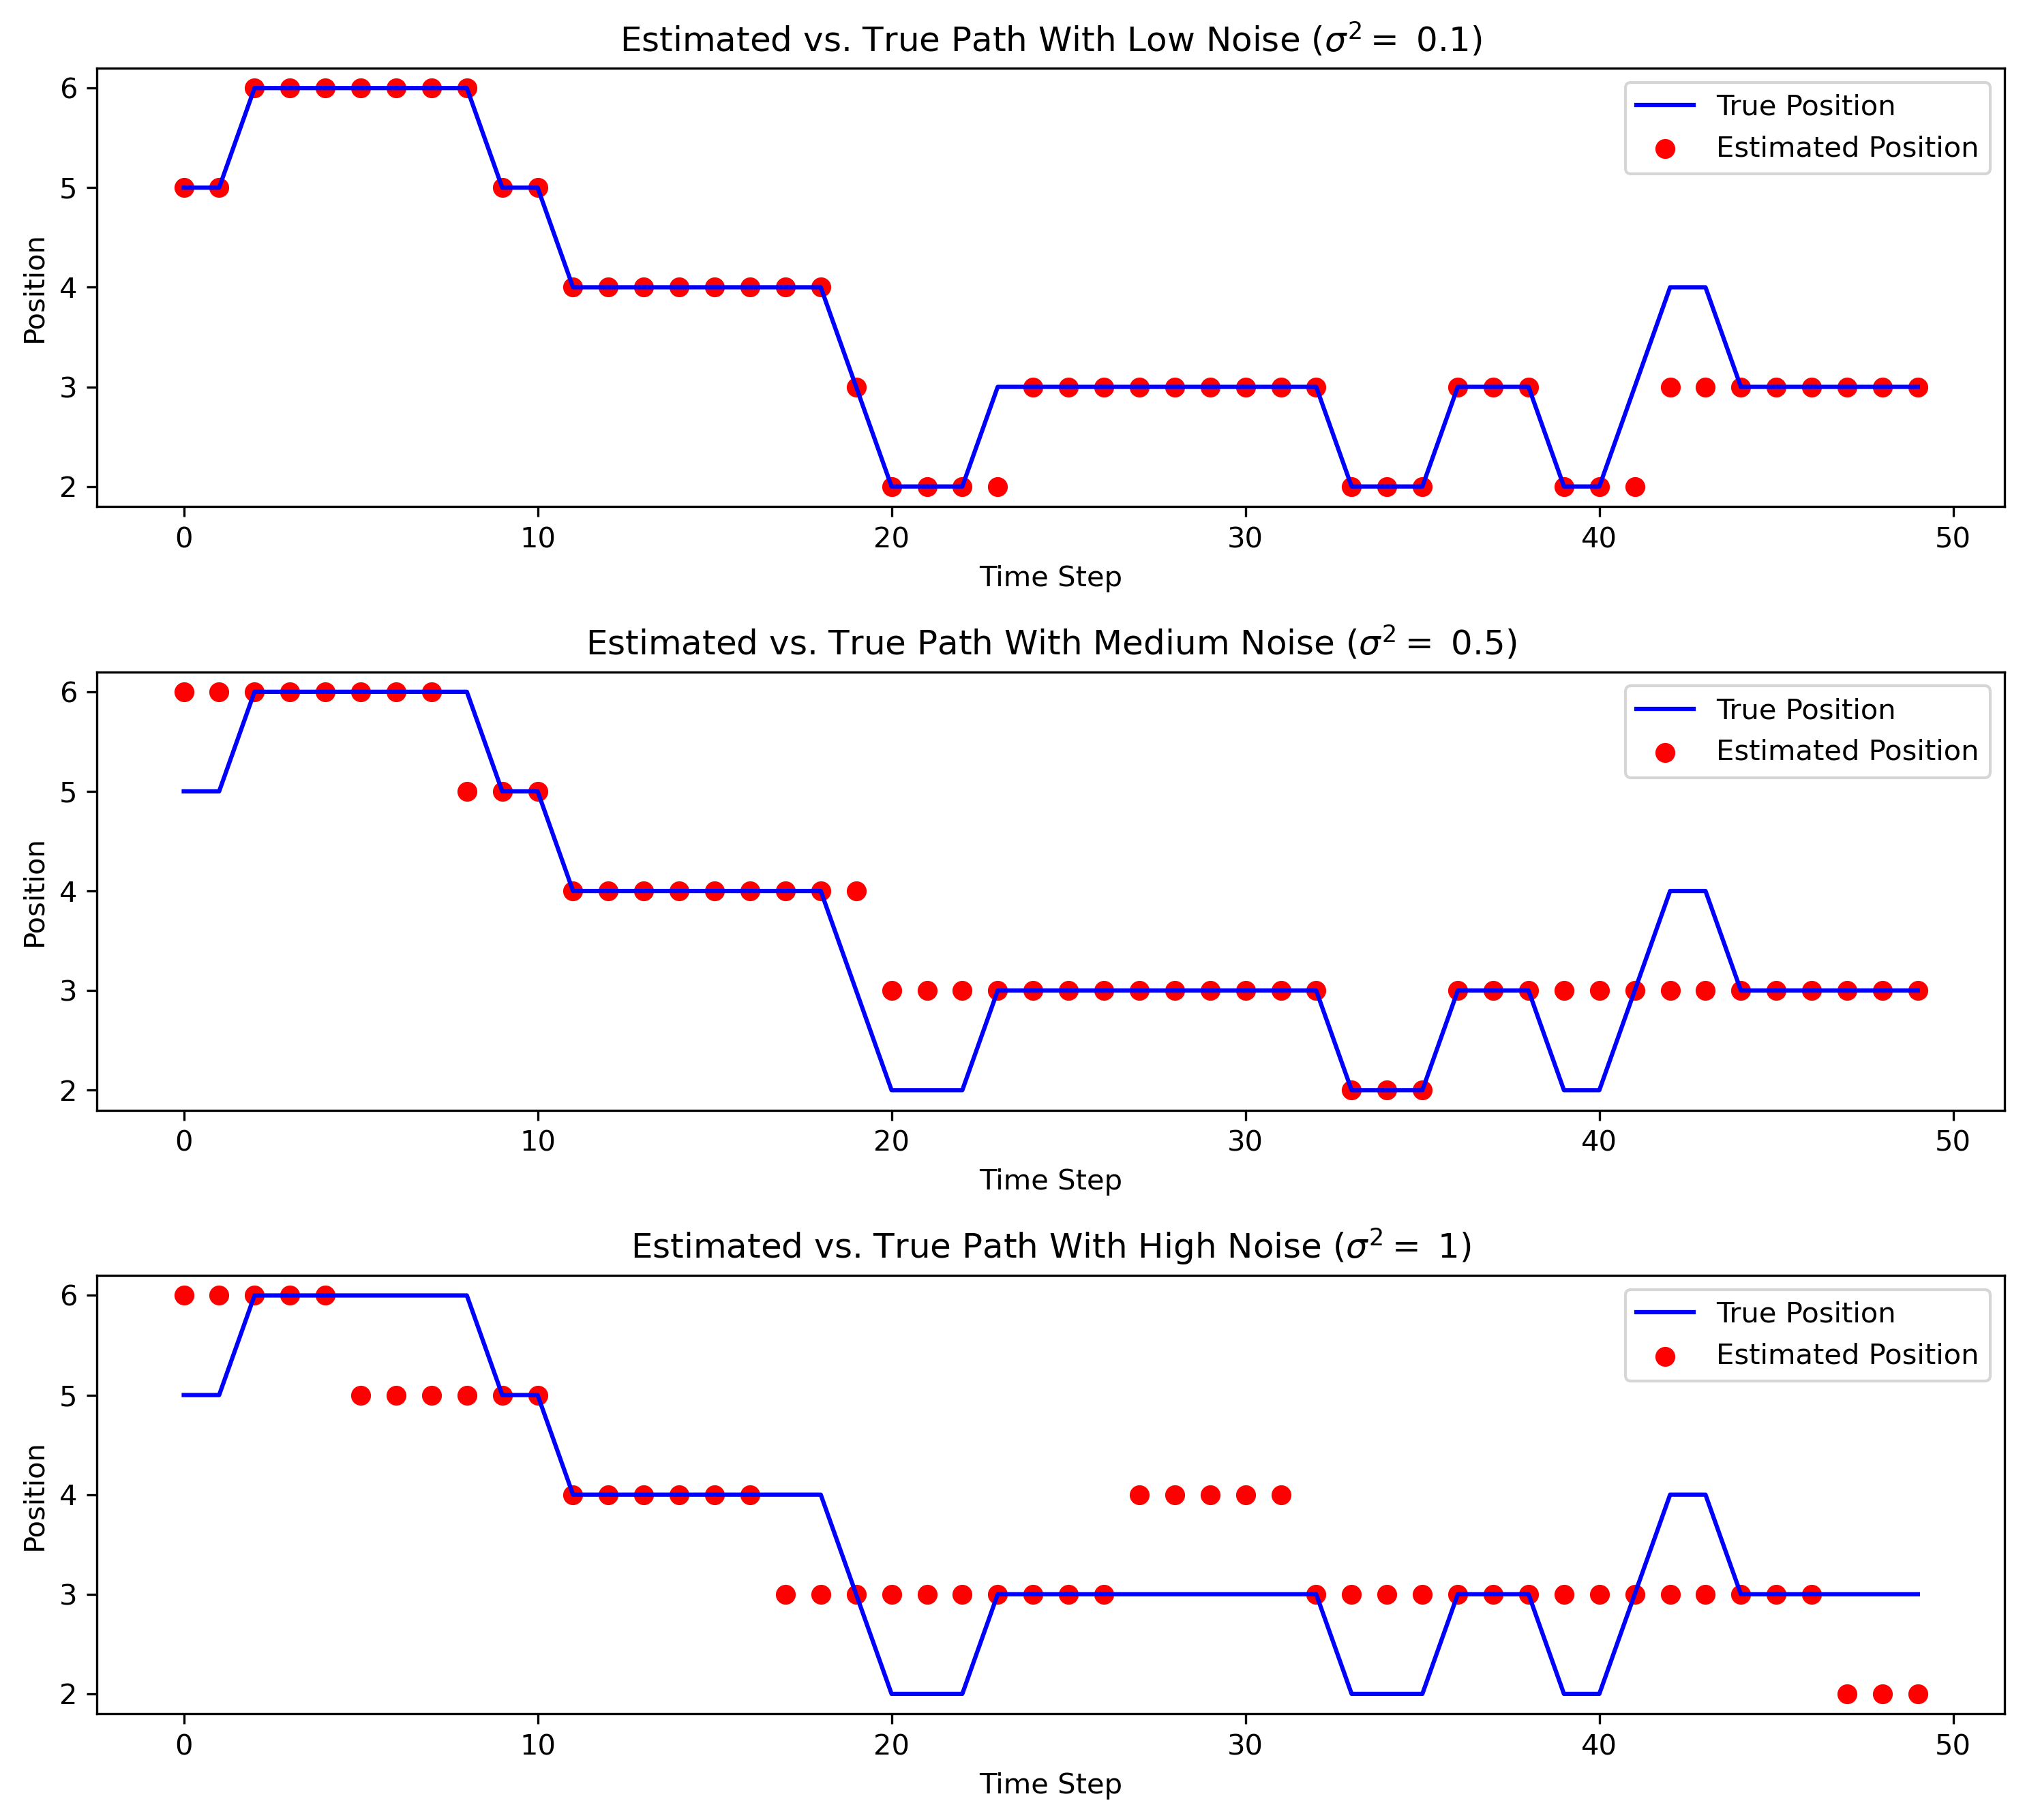

In [33]:
import scipy.stats as stats

Variance = {"Low": 0.1, "Medium": 0.5, "High": 1}
StateTransitionMatrix = statetransitions
StateCount = 11
TimeStepCount = 50
Positions = path
TimeSteps = np.arange(TimeStepCount)

def MakeProbabilityMatrix(StateCount, TimeStepCount, Observations, Variance):
    # Mean is assumed to be state value

    ProbabilityMatrix = np.zeros((StateCount, TimeStepCount))
    for TimeStep in range(TimeStepCount):

        CurrentObservation = Observations[TimeStep]

        for State in range(StateCount):

            CurrentPDF = stats.norm(loc = State, scale = np.sqrt(Variance))

            ObservationProbability = CurrentPDF.pdf(CurrentObservation)

            ProbabilityMatrix[State, TimeStep] = ObservationProbability

    return ProbabilityMatrix

sequencearr = np.zeros((3,50))

Figure, Axes = plt.subplots(3,figsize=(10,9))

for Index, (Name, Value) in enumerate(Variance.items()):

    Noise = np.random.normal(0.0, np.sqrt(Value), len(Positions))
    Path = Positions + Noise

    ProbabilityMatrix = MakeProbabilityMatrix(StateCount, TimeStepCount, Path, np.sqrt(Value))

    Sequence = lb.sequence.viterbi(ProbabilityMatrix, StateTransitionMatrix)
    sequencearr[Index,:] = Sequence
    plt.subplot(3,1,Index+1)
    plt.plot(TimeSteps, Positions, c='blue')
    plt.scatter(TimeSteps, Sequence, c='red')
    plt.legend(["True Position", "Estimated Position"])
    Axes[Index].set_xlabel("Time Step")
    Axes[Index].set_ylabel("Position")
    Axes[Index].set_title(f"Estimated vs. True Path With {Name} Noise ($\sigma^2=$ {Value})")

Figure.dpi = 300
Figure.tight_layout()




In [34]:
sequencearr[1]

array([6., 6., 6., 6., 6., 6., 6., 6., 5., 5., 5., 4., 4., 4., 4., 4., 4.,
       4., 4., 4., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 2.,
       2., 2., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3.])

In [ ]:
for i in range(len(sequencearr)):
    accuracy = np.sum(Positions==sequencearr[i]) 
    perc = accuracy/len(sequencearr[i])
    print(variancenames[i] +":   "+ str(perc))

low:   0.92
med:   0.78
high:   0.48


# 2

In [119]:
# import np.ndarray.flatten

In [162]:
transitions = np.zeros((121, 121))

transitionsquarefull    =   np.array([[0,0.05, 0],[0.05, 0.8,0.05],[0, 0.05, 0]])

transitionsquareleft  =     np.array([[0.05, 0],[0.85,0.05],[0.05, 0]])
transitionsquareright =     np.array([[0,0.05],[0.05, 0.85],[0,0.05]])

transitionsquaretopcorn =   np.array([[0.9,0.05],[0.05, 0]])
transitionsquaretopcorn_r = np.array([[0.05, 0.9],[0,0.05]])
transitionsquaretop     =   np.array([[0.05, 0.85, 0.05],[0,0.05, 0]])

transitionsquarebotcorn =   np.array([[0,0.05],[0.05, 0.9]])
transitionsquarebotcorn_l = np.array([[0.05, 0],[0.9,0.05]])
transitionsquarebot     =   np.array([[0,0.05,0],[0.05,0.85,0.05]])

width = 11
nstates = width*width
for i in range(width):
    for j in range(width):

        mappingsquare = np.zeros((11, 11))
        if i == 0 and j == 0:
            mappingsquare[0:2, 0:2] = transitionsquaretopcorn

        elif i == 0 and j == 10:
            mappingsquare[0:2, 9:11] = transitionsquaretopcorn_r

        elif i == 10 and j == 0:
            mappingsquare[9:11, 0:2] = transitionsquarebotcorn_l

        elif i == 10 and j == 10:
            mappingsquare[9:11, 9:11] = transitionsquarebotcorn

        elif i == 0:
            mappingsquare[0:2, j-1:j+2] = transitionsquaretop

        elif i == 10:
            mappingsquare[9:11, j-1:j+2] = transitionsquarebot

        elif j == 0:
            mappingsquare[i-1:i+2, 0:2] = transitionsquareleft

        elif j == 10:
            mappingsquare[i-1:i+2, 9:11] = transitionsquareright
        else:
            mappingsquare[i-1:i+2, j-1:j+2] = transitionsquarefull

        transitions[i * width + j, :] = mappingsquare.flatten()
        # print(f"{mappingsquare} \n \n ")

In [330]:
numtimesteps = 50
numexperiments = 5
var = 1
cov = np.eye(2) * var
mean = [0,0]
noise = np.random.multivariate_normal(mean,cov,numtimesteps)

startpos = [5,5]
statestate = startpos[0]*width+startpos[1]

cumstatetransitions = np.cumsum(transitions,1)
            
print(cumstatetransitions)

[[0.9  0.95 0.95 ... 1.   1.   1.  ]
 [0.05 0.9  0.95 ... 1.   1.   1.  ]
 [0.   0.05 0.9  ... 1.   1.   1.  ]
 ...
 [0.   0.   0.   ... 0.95 1.   1.  ]
 [0.   0.   0.   ... 0.1  0.95 1.  ]
 [0.   0.   0.   ... 0.05 0.1  1.  ]]


In [331]:

statearr = np.zeros([numexperiments,numtimesteps],dtype=np.int32)
statearr[:,0] = statestate

for experiment in range(numexperiments):
    rand = rnd.uniform(low=0,high=1,size=numtimesteps)
    for currenttime in range(1,numtimesteps):
        lastposition = int(statearr[experiment,currenttime-1])
        loc = np.where( rand[currenttime] <= cumstatetransitions[lastposition,:])
        statearr[experiment,currenttime] = int(np.min(loc[0][0]))

realpos = np.unravel_index(statearr,(11,11))
# statearr = np.transpose(statearr)

In [332]:
np.shape(realpos[1])
# np.shape(realpos)[1]
# realpos[1][9,:]
# statearr[0,:]

(5, 50)

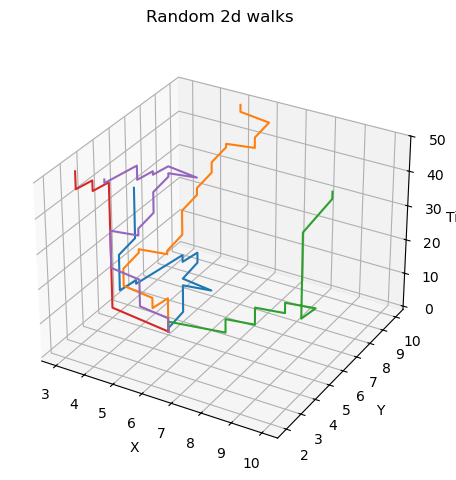

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(111,projection='3d') #.subplots(projection='3d')
for i in range(np.shape(realpos[0])[0]):
    x = realpos[0][i,:]
    y = realpos[1][i,:]
    z = np.arange(0,len(x))
    ax.plot(x, y, z)
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Time")
fig.suptitle("Random 2d walks")
fig.tight_layout()

idx: 0, key: One, val: 1
idx: 1, key: Five, val: 5
idx: 2, key: Twenty, val: 20


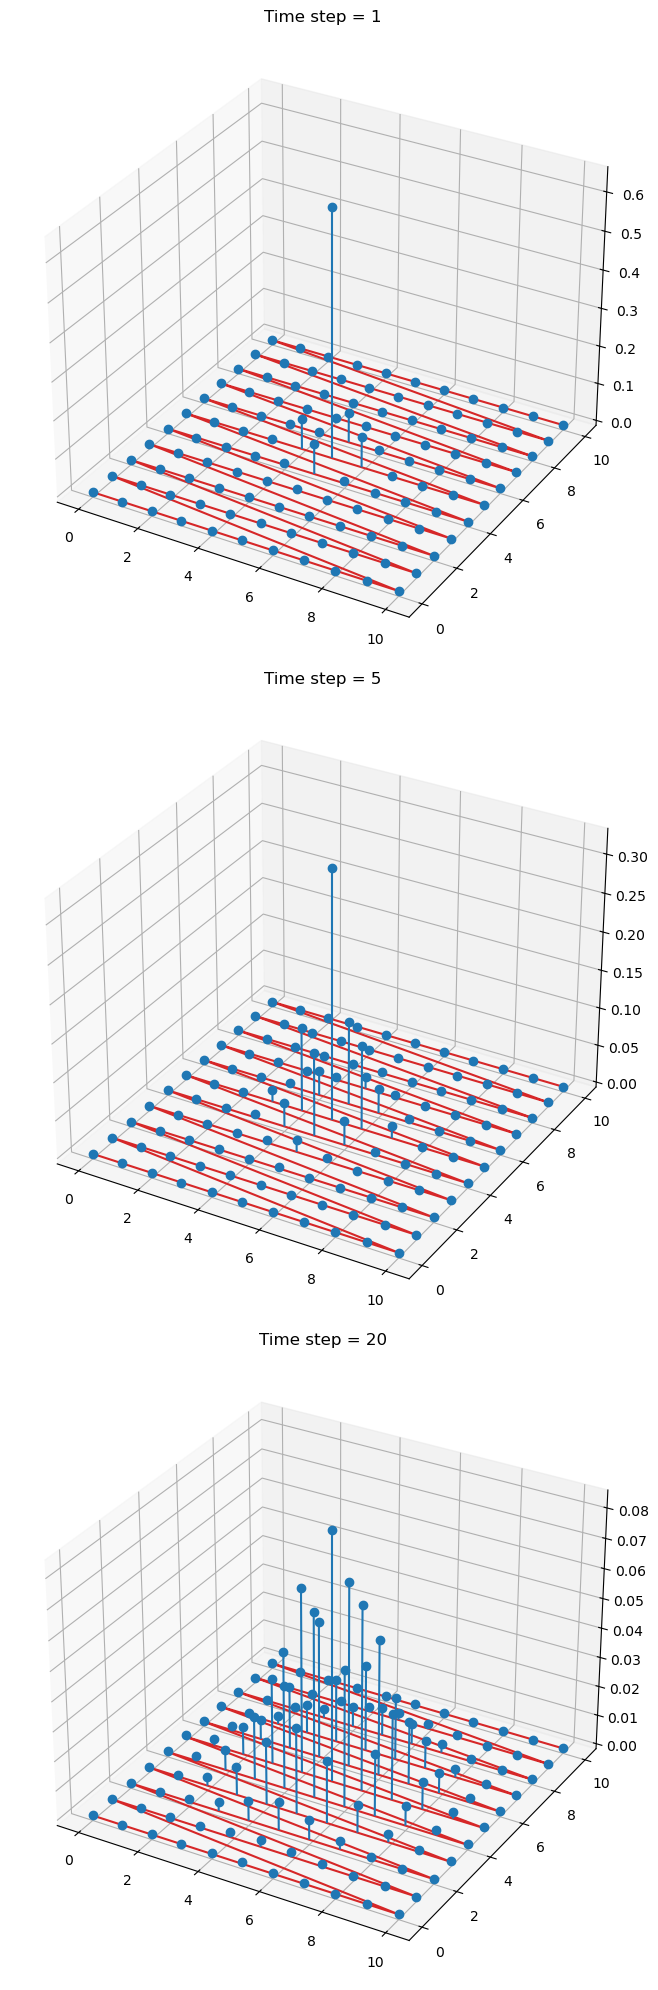

In [392]:
numsteps = {"One": 1, "Five": 5, "Twenty": 20}
# plt.close()
fig = plt.figure(figsize=(20,20))

for idx, (key, val) in enumerate(numsteps.items()):
    ax = fig.add_subplot(3,1,idx+1, projection="3d")
    print(f"idx: {idx}, key: {key}, val: {val}")
    
    pow = matrixpower(transitions, val) 
    currentpositionpmf = np.array(pow[60, :], dtype=np.float64)  
    x = np.tile(np.arange(0, 11), 11)
    y = np.repeat(np.arange(0, 11), 11) 

    ax.stem(x, y, currentpositionpmf.reshape(-1))
    ax.set_title("Time step = " + str(val))

fig.tight_layout()
